# B05 · TabDPT: real-data episodes and retrieval

**Goal:** build target-safe episodes and defend source/reproduction boundaries. Complete the three TODO functions before reading the solution. Author checks do not satisfy your written defense.

The portable default replays all saved course evidence, executes your episode construction and checks frozen source identities. It does not download model weights, train TabDPT or dispatch the gated banknote experiment. Optional fresh course regeneration and released-method probe are separate commands below. Dependencies: Python3.10+ and NumPy; default checks need no GPU. Live Colab NOT_CHECKED.


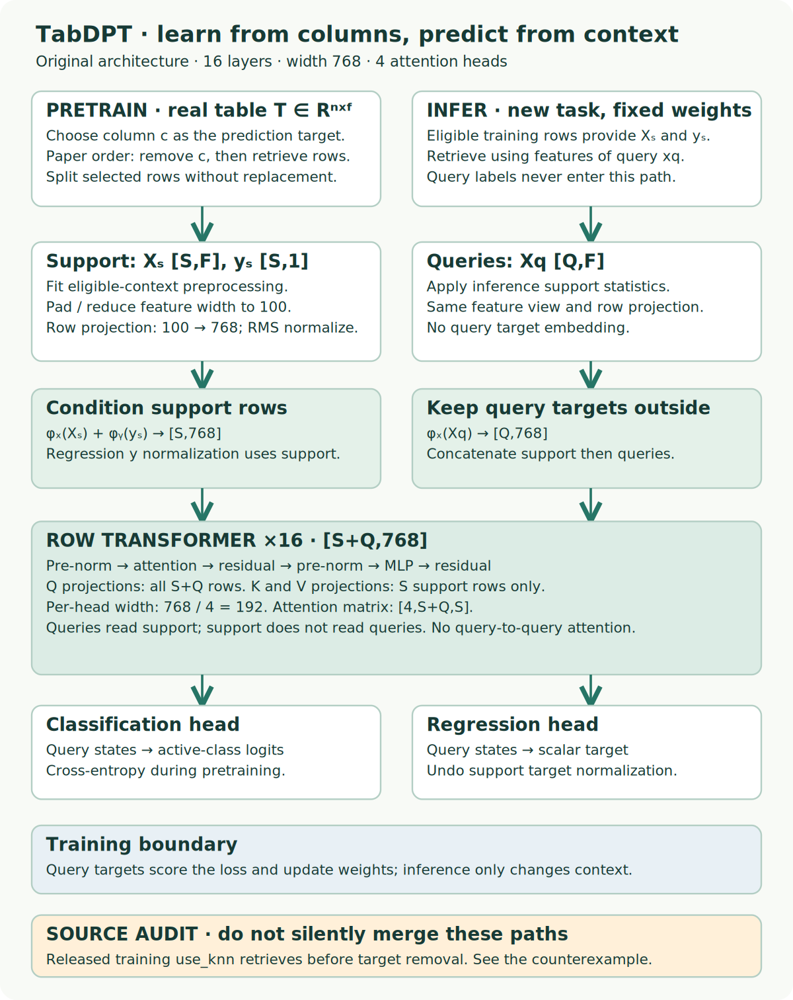

**Retrieve:** identify S,Q,F and the K/V slice before opening the source. Why does deleting y after neighbor selection fail? Trace `[32,12] → [32,100] → [32,768]`, then the `[4,32,24]` attention matrices. Only pretraining updates weights. The original source uses whole-episode feature normalization in training and support statistics in inference.


In [ ]:
import importlib.util, subprocess, sys
if importlib.util.find_spec('numpy') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==2.2.6'])
import ast, base64, hashlib, io, json, math, itertools, zipfile
from pathlib import Path
import numpy as np


In [ ]:
payload = '...'
raw = base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest() == '2bf98d284ad27b9594c71a9d10e6a86375ee799ae375e993b5e654e49637e911'
workspace = Path('b05-portable')
workspace.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as bundle:
    bundle.extractall(workspace)
lab = workspace / 'labs'
sys.path.insert(0, str(lab.resolve()))
evidence = lab / 'evidence/b05'
print('Authenticated portable source/evidence package')

## TODO 1–3 · Implement the information contract

`feature_view` removes c before fitting distances. `neighbors` fits scales on support, handles constant columns and breaks ties by identity. `overlap_status` never upgrades different hashes to independence. The provided `episode` function calls your implementations.

In [ ]:
"""B05 course mechanisms, deliberately distinct from the released pretraining sampler."""
import numpy as np

def feature_view(table, target):
    raise NotImplementedError("TODO: feature_view")

def neighbors(support, query, ids, k):
    raise NotImplementedError("TODO: neighbors")

def episode(table, target, anchor, size, support_n, seed):
    """Paper-order teaching episode: remove target, retrieve, then partition once."""
    x,y=feature_view(table,target)
    if not 0<=anchor<len(x) or not 0<support_n<size<=len(x):raise ValueError('Invalid episode sizes')
    selected=neighbors(x,x[[anchor]],np.arange(len(x)),size)[0]
    order=np.random.default_rng(seed).permutation(selected);s=order[:support_n];q=order[support_n:]
    return dict(selected_ids=selected.tolist(),support_ids=s.tolist(),query_ids=q.tolist(),support_x=x[s].tolist(),query_x=x[q].tolist(),support_y=y[s].tolist(),query_y=y[q].tolist())

def overlap_status(train, test):
    raise NotImplementedError("TODO: overlap_status")


In [ ]:
def check_feature_view(fn):
    t=np.array([[0.,99.,3.],[1.,12.,4.]])
    x,y=fn(t,1);np.testing.assert_array_equal(x,[[0,3],[1,4]]);np.testing.assert_array_equal(y,[99,12])
    x[0,0]=88;assert t[0,0]==0,'Views must not mutate source'
    for target in [-1,3]:
        try:fn(t,target)
        except ValueError:pass
        else:raise AssertionError('Invalid target accepted')

def check_neighbors(fn):
    s=np.array([[0.,0.],[2.,0.],[4.,0.]])
    assert fn(s,[[1.,9.]],[8,2,5],2).tolist()==[[2,8]],'Tie must use row identity'
    a=fn(s,[[1,9],[100,0]],[8,2,5],2);b=fn(s,[[1,9]],[8,2,5],2)
    np.testing.assert_array_equal(a[:1],b)
    for ids,k in [([1,1,2],2),([1,2,3],4),([1,2,3],0)]:
        try:fn(s,[[1,0]],ids,k)
        except ValueError:pass
        else:raise AssertionError('Invalid retrieval contract accepted')

def check_overlap(fn):
    base=dict(dataset_id=1,name='first',sha256='a',family='family-a')
    assert fn(base,dict(base))=='OVERLAP'
    assert fn(base,dict(dataset_id=2,name='renamed',sha256='a',family='unknown'))=='OVERLAP'
    assert fn(base,dict(dataset_id=2,name='renamed',sha256='b',family='family-a'))=='RELATED'
    assert fn(base,dict(dataset_id=2,name='other',sha256='b',family='family-b'))=='NOT_ESTABLISHED'

check_feature_view(feature_view)
check_neighbors(neighbors)
check_overlap(overlap_status)
print("Three learner contracts pass")

## CHECK · Your episode must drive measured identities

All18settings are checked. This calls the notebook functions, not a saved completion flag. The four-neighbor mean is a course readout, not a trained TabDPT.

In [ ]:
inputs = json.loads((evidence/'inputs.json').read_text())
records = json.loads((evidence/'episodes.json').read_text())
for saved in records:
    ep = episode(inputs['X'], saved['target'], saved['seed'], saved['size'], saved['size']-8, saved['seed'])
    for key in ep:
        assert ep[key] == saved[key], key
    nn = neighbors(ep['support_x'], ep['query_x'], ep['support_ids'], 4)
    assert nn.tolist() == saved['neighbor_ids']
changed = np.array(inputs['X']); changed[:,0] = changed[::-1,0]
a = episode(inputs['X'],0,0,32,24,0)
b = episode(changed,0,0,32,24,0)
assert a['selected_ids'] == b['selected_ids']
print('18 episodes and 144 neighbor selections agree; target intervention passes')

## Independent audit · read the oracle before running

These scalar loops recompute distances and predictions from the frozen raw table. MSE is not pooled across target units. Larger episodes do not preserve query IDs.

In [ ]:
"""Independent scalar retrieval and scoring; authenticate every episode and query."""

import hashlib,json,math,itertools

from pathlib import Path

def scalar_neighbors(support,queries,ids,k):
    f=len(support[0]);n=len(support)
    means=[sum(row[j] for row in support)/n for j in range(f)]
    scales=[math.sqrt(sum((row[j]-means[j])**2 for row in support)/n) or 1 for j in range(f)]
    return [[identity for _,identity in sorted((sum(((q[j]-row[j])/scales[j])**2 for j in range(f)),identity) for row,identity in zip(support,ids))[:k]] for q in queries]

def audit_course(root):
    root=Path(root);p=json.loads((root/'course-protocol.json').read_text());raw=(root/'inputs.json').read_bytes()
    assert hashlib.sha256(raw).hexdigest()==p['input_sha256'],'Input hash'
    inputs=json.loads(raw);table=inputs['X'];records=json.loads((root/'episodes.json').read_text())
    expected=set(itertools.product(p['targets'],p['seeds'],p['episode_sizes']));seen=set();summary=[];total=0
    for r in records:
        key=(r['target'],r['seed'],r['size']);assert key in expected and key not in seen,'Missing/duplicate setting';seen.add(key)
        t,seed,size=key;x=[row[:t]+row[t+1:] for row in table]
        selected=scalar_neighbors(x,[x[seed]],list(range(len(x))),size)[0]
        assert r['selected_ids']==selected==r['target_intervention_ids'],'Selection identities'
        s=r['support_ids'];q=r['query_ids'];assert len(s)==size-8 and len(q)==8
        assert len(set(s+q))==size and set(s+q)==set(selected),'Partition keys'
        assert r['support_x']==[x[i] for i in s] and r['query_x']==[x[i] for i in q],'Feature identity'
        assert r['support_y']==[table[i][t] for i in s] and r['query_y']==[table[i][t] for i in q],'Label identity'
        nn=scalar_neighbors([x[i] for i in s],[x[i] for i in q],s,4);assert nn==r['neighbor_ids'],'Neighbor identity'
        pred=[sum(table[i][t] for i in ids)/4 for ids in nn]
        assert len(r['prediction'])==8 and all(math.isfinite(z) for z in r['prediction'])
        assert all(abs(a-b)<1e-10 for a,b in zip(pred,r['prediction'])),'Prediction values'
        mse=sum((a-table[i][t])**2 for a,i in zip(pred,q))/8;total+=8
        summary.append(dict(target=t,seed=seed,size=size,mse=mse))
    assert seen==expected,'Incomplete matrix'
    return dict(status='COMPLETE_COURSE_MECHANISM',episodes=len(records),predictions=total,independent_neighbors='PASS',all_keyed_predictions='PASS',target_interventions='18 selections unchanged',rows=summary,claims='No TabDPT training/inference, benchmark parity or architecture attribution')

In [ ]:
"""Authenticate source evidence and expose unresolved original-paper protocol identities."""

import csv,hashlib,json,re

from pathlib import Path

def source_gate(root):
    root=Path(root);manifest=json.loads((root/'manifest.json').read_text())
    assert not re.search(rb'AIza[0-9A-Za-z_-]{35}',(root/'tabzilla-drive.html').read_bytes()), 'Google API key in saved Drive page'
    for name,digest in manifest['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==digest,'Source hash: '+name
    original=json.loads((root/'original-checkpoint-config.json').read_text())
    later=json.loads(json.loads((root/'checkpoint-header.json').read_text())['__metadata__']['cfg'])
    train=list(csv.DictReader((root/'training/data_splits/noleak_training_datasets.csv').open()))
    evals=list(csv.DictReader((root/'paper-era/tabdpt_datasets/data_splits/cls_datasets.csv').open()))
    bank=[r for r in evals if r['did']=='1462'];assert len(bank)==1 and bank[0]['tid']=='10093.0' and bank[0]['test']=='True'
    train_ids={int(float(r['did'])) for r in train};eval_ids={int(float(r['did'])) for r in evals if r['test']=='True'}
    return dict(name='B05-TABDPT-BANKNOTE-TWO-FOLD',status='INCOMPLETE_SOURCE_PROTOCOL',source_files=len(manifest['files']),original_source='5214f9267b49d3907b074be9d90a660054484416',paper_era_evaluator='eb5c0d9ff303d8fd8a053d9ac8be21af0d4e9157',training_source='af0340c5cdebe2ceb6b94c09d6f9564ee80b89df',original_weight_sha256=json.loads((root/'original-weight-download.json').read_text())['sha256'],original_heads=original['model']['nhead'],later_heads=later['model']['nhead'],dataset_id=1462,task_id=10093,folds=[0,1],context_size=2048,n_ensembles=8,declared_training_rows=len(train),training_unique_ids=len(train_ids),classification_test_ids=len(eval_ids),exact_id_intersection=sorted(train_ids&eval_ids),banknote_in_training_ids=1462 in train_ids,independence='NOT_ESTABLISHED: ID audit only; renamed/derived datasets require content/statistical review',missing=['Authenticated mapping from paper v3 result to original v1.0 versus v1.1 checkpoint and evaluator (4 vs8 heads; later evaluator loads1.1).','Exact bytes and row identities of both TabZilla banknote folds used for the paper; OpenML task ID alone is insufficient.','Original selected banknote per-fold reference scores/predictions and ensemble RNG mapping.'],source_discrepancy='Released pretraining sampler retrieves before target removal; paper Algorithm1 removes target first.',completed_benchmark_runs=0,full_pretraining='NOT_RUN',full_benchmark='NOT_RUN',historical_identity='NOT_ESTABLISHED')

In [ ]:
course = audit_course(evidence)
source = source_gate(lab/'sources/b05')
assert course == json.loads((evidence/'course-audit.json').read_text())
assert source == json.loads((evidence/'source-gate.json').read_text())
report = dict(source=source, course=course)
Path('b05-report.json').write_text(json.dumps(report,indent=2)+'\n')
print(source['status'], course['episodes'], 'episodes,', course['predictions'], 'predictions')
for row in course['rows']: print(row)


## Source probe and optional fresh work

The released `use_knn` method selects [0,2,4] then [0,1,3]under a target-only intervention. The exact L2 test double establishes local method behavior, not FAISS performance or historical training. Full source is below. To rerun the probe, install PyTorch and run `python b05-portable/labs/_source_probe_b05.py`. To regenerate the 18 course episodes, install scikit-learn and run `_run_b05.py` then `_audit_b05.py` in the same directory. The benchmark command `_reproduce_b05.py --run` refuses while original identities are unresolved.

In [ ]:
probe = json.loads((evidence/'sampler-probe.json').read_text())
assert probe['released_neighbors'] == [[0,2,4],[0,1,3]]
assert probe['paper_order_neighbors'] == [[0,1,2],[0,1,2]]
print(probe)


## Version boundary

Original TabDPT, v1.1, Turbo and v1.3 are separate artifacts. The recovered original has 4 attention heads; the later header has 8. Turbo changes target conditioning and uses a shared context without per-query retrieval in its described inference recipe. Its newer scores cannot validate the original selected paper result. [Turbo §3.4](https://arxiv.org/html/2608.01400v1#S3.SS4).

## EXIT · Your written defense

Supply a worked distance, the support-only attention slice, a renamed-table overlap counterexample, and a claim limited to the executed sampler probe. Explain the 4-head/8-head checkpoint issue and why two-fold banknote inference would not measure neighbor pruning. Leave your status pending until the tutor reviews this defense. Revisit after 1/7/30 days following completion. Ask follow-up questions whenever the contract is unclear.

In [ ]:
defense = {'distance_trace': '', 'attention_boundary': '', 'overlap_counterexample': '', 'source_claim': ''}
submission = dict(status='PENDING_WRITTEN_DEFENSE', defense=defense)
Path('b05-submission.json').write_text(json.dumps(submission,indent=2)+'\n')
print(submission['status'])

## Complete visible source appendix

Original architecture, release preprocessing/retrieval and training sampler remain separate from the course functions. Source licenses accompany the archive. Primary reading: https://arxiv.org/html/2410.18164v3#S3 and https://arxiv.org/html/2608.01400v1#S3.

### sources/b05/original/src/tabdpt/__init__.py

```python
from .classifier import TabDPTClassifier
from .regressor import TabDPTRegressor

__all__ = ['TabDPTClassifier', 'TabDPTRegressor']
```

### sources/b05/original/src/tabdpt/classifier.py

```python
import numpy as np
from tqdm import tqdm
from scipy.special import softmax
import torch
import math
from sklearn.base import ClassifierMixin
from .estimator import TabDPTEstimator
from .utils import pad_x, generate_random_permutation


class TabDPTClassifier(TabDPTEstimator, ClassifierMixin):
    def __init__(self, path: str = '', inf_batch_size: int = 512, device: str = 'cuda:0', use_flash: bool = True, compile: bool = True):
        super().__init__(path=path, mode='cls', inf_batch_size=inf_batch_size, device=device, use_flash=use_flash, compile=compile)
        
    def fit(self, X, y):
        super().fit(X, y)
        self.num_classes = len(np.unique(self.y_train))
        assert self.num_classes > 1, "Number of classes must be greater than 1"
        
    def _predict_large_cls(self, X_train, X_test, y_train):
        num_digits = math.ceil(math.log(self.num_classes, self.max_num_classes))
        
        digit_preds = []
        for i in range(num_digits):
            y_train_digit = (y_train // (self.max_num_classes ** i)) % self.max_num_classes
            pred = self.model(
                x_src=torch.cat([X_train, X_test], dim=1),
                y_src=y_train_digit.unsqueeze(-1),
                task='cls',
            )
            digit_preds.append(pred.float())

        full_pred = torch.zeros((X_test.shape[0], X_test.shape[1], self.num_classes), device=X_train.device)
        for class_idx in range(self.num_classes):
            class_pred = torch.zeros_like(digit_preds[0][:, :, 0])
            for digit_idx, digit_pred in enumerate(digit_preds):
                digit_value = (class_idx // (self.max_num_classes ** digit_idx)) % self.max_num_classes
                class_pred += digit_pred[:, :, digit_value]
            full_pred[:, :, class_idx] = class_pred

        return full_pred

    @torch.no_grad()
    def predict_proba(self, X: np.ndarray, temperature: float = 0.8, context_size: int = 128, return_logits: bool = False, seed: int = None):
        train_x, train_y, test_x = self._prepare_prediction(X)
        
        if seed is not None:
            feat_perm = generate_random_permutation(train_x.shape[1], seed)
            train_x = train_x[:, feat_perm]
            test_x = test_x[:, feat_perm]

        if context_size >= self.n_instances:
            X_train = pad_x(train_x[None, :, :], self.max_features).to(self.device)
            X_test = pad_x(test_x[None, :, :], self.max_features).to(self.device)
            y_train = train_y[None, :].float()
            
            if self.num_classes <= self.max_num_classes:
                pred = self.model(
                    x_src=torch.cat([X_train, X_test], dim=1),
                    y_src=y_train.unsqueeze(-1),
                    task=self.mode,
                )
            else:
                pred = self._predict_large_cls(X_train, X_test, y_train)
            
            pred = pred[..., :self.num_classes] / temperature
            pred = torch.nn.functional.softmax(pred, dim=-1)
            pred_val = pred.float().squeeze().detach().cpu().numpy()
        else:
            pred_list = []
            for b in range(math.ceil(len(self.X_test) / self.inf_batch_size)):
                start = b * self.inf_batch_size
                end = min(len(self.X_test), (b + 1) * self.inf_batch_size)

                indices_nni = self.faiss_knn.get_knn_indices(
                    self.X_test[start:end], k=context_size
                )
                X_nni = train_x[torch.tensor(indices_nni)]
                y_nni = train_y[torch.tensor(indices_nni)]

                X_nni, y_nni = (
                    pad_x(torch.Tensor(X_nni), self.max_features).to(self.device),
                    torch.Tensor(y_nni).to(self.device),
                )
                X_eval = test_x[start:end]
                X_eval = pad_x(X_eval.unsqueeze(1), self.max_features).to(self.device)
                
                if self.num_classes <= self.max_num_classes:
                    pred = self.model(
                        x_src=torch.cat([X_nni, X_eval], dim=1),
                        y_src=y_nni.unsqueeze(-1),
                        task=self.mode,
                    )
                else:
                    pred = self._predict_large_cls(X_nni, X_eval, y_nni)

                if not return_logits:
                    pred = pred[..., :self.num_classes].float() / temperature
                    pred = torch.nn.functional.softmax(pred, dim=-1)
                    pred /= pred.sum(axis=-1, keepdims=True) # numerical stability

                pred_list.append(pred.squeeze())
            pred_val = torch.cat(pred_list, dim=0).squeeze().detach().cpu().float().numpy()
        return pred_val
        
    def ensemble_predict_proba(self, X, n_ensembles: int, temperature: float = 0.8, context_size: int = 128):
        logits_cumsum = None
        for i in tqdm(range(n_ensembles)):
            seed = int(np.random.SeedSequence().generate_state(1)[0])
            logits = self.predict_proba(X, context_size=context_size, return_logits=True, seed=seed)
            if logits_cumsum is None:
                logits_cumsum = logits
            else:
                logits_cumsum += logits
        
        pred = (logits_cumsum / n_ensembles)[..., :self.num_classes] / temperature
        pred = softmax(pred, axis=-1)
        pred /= pred.sum(axis=-1, keepdims=True) # numerical stability
        return pred
        
    def predict(self, X, n_ensembles: int = 1, temperature: float = 0.8, context_size: int = 128, seed: int = None):
        if n_ensembles == 1:
            return self.predict_proba(X, temperature=temperature, context_size=context_size, seed=seed).argmax(axis=-1)
        else:
            return self.ensemble_predict_proba(X, n_ensembles=n_ensembles, temperature=temperature, context_size=context_size).argmax(axis=-1)

```

### sources/b05/original/src/tabdpt/estimator.py

```python
import torch
import numpy as np

from sklearn.base import BaseEstimator
from sklearn.utils.validation import check_is_fitted
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from .model import TabDPTModel
from .utils import convert_to_torch_tensor, FAISS, download_model


class TabDPTEstimator(BaseEstimator):
    def __init__(self, path: str = '', mode: str = "cls", inf_batch_size: int = 512, device: str = 'cuda:0', use_flash: bool = True, compile: bool = True):
        self.mode = mode
        self.inf_batch_size = inf_batch_size
        self.device = device
        # automatically download model weight if path is empty
        if path == '':
            path = download_model()
        checkpoint = torch.load(path, map_location='cpu')
        checkpoint['cfg']['env']['device'] = self.device
        self.model = TabDPTModel.load(model_state=checkpoint['model'], config=checkpoint['cfg'], use_flash=use_flash)
        self.model.eval()
        self.max_features = self.model.num_features
        self.max_num_classes = self.model.n_out
        self.compile = compile
        assert self.mode in ['cls', 'reg'], "mode must be 'cls' or 'reg'"

    def fit(self, X, y):
        assert isinstance(X, np.ndarray), "X must be a numpy array"
        assert isinstance(y, np.ndarray), "y must be a numpy array"
        assert X.shape[0] == y.shape[0], "X and y must have the same number of samples"
        assert X.ndim == 2, "X must be a 2D array"
        assert y.ndim == 1, "y must be a 1D array"

        self.imputer = SimpleImputer(strategy='mean')
        X = self.imputer.fit_transform(X)
        self.scaler = StandardScaler()
        X = self.scaler.fit_transform(X)
        
        self.faiss_knn = FAISS(X)
        self.n_instances, self.n_features = X.shape
        self.X_train = X
        self.y_train = y
        self.is_fitted_ = True
        if self.compile:
            self.model = torch.compile(self.model)
        
    def _prepare_prediction(self, X: np.ndarray):
        check_is_fitted(self)
        self.X_test = self.imputer.transform(X)
        self.X_test = self.scaler.transform(self.X_test)
        train_x, train_y, test_x = (
            convert_to_torch_tensor(self.X_train).to(self.device).float(),
            convert_to_torch_tensor(self.y_train).to(self.device).float(),
            convert_to_torch_tensor(self.X_test).to(self.device).float(),
        )

        # Apply PCA optionally to reduce the number of features
        if self.n_features > self.max_features:
            U, S, self.V = torch.pca_lowrank(train_x, q=self.max_features)
            train_x = train_x @ self.V
        else:
            self.V = None
        
        test_x = test_x @ self.V if self.V is not None else test_x
        return train_x, train_y, test_x

```

### sources/b05/original/src/tabdpt/model.py

```python
from typing import Literal

import torch
import torch.nn as nn
import torch.nn.functional as F
from .utils import normalize_data, clip_outliers, flash_context

class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        bias = True  # Set bias=True to match the original model
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads
        self.kv_proj = nn.Linear(embed_dim, 2 * embed_dim, bias=bias)
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=bias)
        self.attn_norm = nn.LayerNorm(embed_dim)
        self.ff_norm = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )

    def forward(self, x, eval_pos):
        B, L, _ = x.size()
        h = self.attn_norm(x)
        q = self.q_proj(h)
        k, v = self.kv_proj(h[:, :eval_pos]).chunk(2, dim=-1)
        q = q.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, eval_pos, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, eval_pos, self.num_heads, self.head_dim).transpose(1, 2)
        attn = F.scaled_dot_product_attention(q, k, v).transpose(1, 2)
        attn = self.out_proj(attn.reshape(B, L, self.embed_dim))
        x = x + attn
        x = x + self.ff(self.ff_norm(x))
        return x

class TabDPTModel(nn.Module):
    def __init__(self, dropout: float, n_out: int, nhead: int, nhid: int, ninp: int, nlayers: int, norm_first: bool, num_features: int, use_flash: bool):
        super().__init__()
        self.n_out = n_out
        self.num_features = num_features
        self.encoder = nn.Linear(num_features, ninp)
        self.y_encoder = nn.Linear(1, ninp)
        self.cls_head = nn.Sequential(nn.Linear(ninp, nhid), nn.GELU(), nn.Linear(nhid, n_out))
        self.reg_head = nn.Sequential(nn.Linear(ninp, nhid), nn.GELU(), nn.Linear(nhid, 1))
        self.task2head = {'cls': self.cls_head, 'reg': self.reg_head}
        self.transformer_encoder = nn.ModuleList(
            [
                TransformerEncoderLayer(embed_dim=ninp, num_heads=nhead, ff_dim=nhid)
                for _ in range(nlayers)
            ]
        )
        self.use_flash = torch.cuda.is_available() and use_flash

    @flash_context
    def forward(
        self,
        x_src: torch.Tensor,
        y_src: torch.Tensor,
        task: Literal["cls", "reg"],  # classification or regression
    ) -> torch.Tensor:
        eval_pos = y_src.shape[1]
        x_src = normalize_data(x_src, -1 if self.training else eval_pos)
        
        x_src = clip_outliers(x_src, -1 if self.training else eval_pos, n_sigma=10)
        if task == "reg":
            y_src, mean_y, std_y = normalize_data(y_src, return_mean_std=True)
            y_src = clip_outliers(y_src)
        
        x_src = torch.nan_to_num(x_src, nan=0)

        x_src = self.encoder(x_src)

        mean = (x_src**2).mean(dim=-1, keepdim=True)
        rms = torch.sqrt(mean)
        x_src = x_src / rms

        y_src = self.y_encoder(y_src)
        train_x = x_src[:, :eval_pos] + y_src
        src = torch.cat([train_x, x_src[:, eval_pos:]], 1)

        for layer in self.transformer_encoder:
            src = layer(src, eval_pos)
        pred = self.task2head[task](src)

        if task == "reg":
            pred = pred * std_y + mean_y

        return pred[:, eval_pos:]

    @classmethod
    def load(cls, model_state, config, use_flash):
        model = TabDPTModel(
            dropout=config['training']['dropout'],
            n_out=config['model']['max_num_classes'],
            nhead=config['model']['nhead'],
            nhid=config['model']['emsize'] * config['model']['nhid_factor'],
            ninp=config['model']['emsize'],
            nlayers=config['model']['nlayers'],
            norm_first=config['model']['norm_first'],
            num_features=config['model']['max_num_features'],
            use_flash=use_flash
        )

        # Remove any module prefixes if necessary
        module_prefix = '_orig_mod.'
        model_state = {k.replace(module_prefix, ''): v for k, v in model_state.items()}

        # Mapping function to convert state_dict keys
        def map_state_dict(original_state_dict, model):
            new_state_dict = {}
            for key, value in original_state_dict.items():
                if key.startswith('transformer_encoder.'):
                    # Handle transformer encoder layers
                    parts = key.split('.')
                    layer_idx = parts[1]
                    sub_module = parts[2]
                    param_name = '.'.join(parts[3:])
                    if sub_module == 'self_attn':
                        if param_name == 'in_proj_weight':
                            in_proj_weight = value
                            embed_dim = model.transformer_encoder[int(layer_idx)].embed_dim
                            q_proj_weight = in_proj_weight[:embed_dim, :]
                            k_proj_weight = in_proj_weight[embed_dim:2*embed_dim, :]
                            v_proj_weight = in_proj_weight[2*embed_dim:, :]
                            kv_proj_weight = torch.cat([k_proj_weight, v_proj_weight], dim=0)
                            new_state_dict[f'transformer_encoder.{layer_idx}.q_proj.weight'] = q_proj_weight
                            new_state_dict[f'transformer_encoder.{layer_idx}.kv_proj.weight'] = kv_proj_weight
                        elif param_name == 'in_proj_bias':
                            in_proj_bias = value
                            embed_dim = model.transformer_encoder[int(layer_idx)].embed_dim
                            q_proj_bias = in_proj_bias[:embed_dim]
                            k_proj_bias = in_proj_bias[embed_dim:2*embed_dim]
                            v_proj_bias = in_proj_bias[2*embed_dim:]
                            kv_proj_bias = torch.cat([k_proj_bias, v_proj_bias], dim=0)
                            new_state_dict[f'transformer_encoder.{layer_idx}.q_proj.bias'] = q_proj_bias
                            new_state_dict[f'transformer_encoder.{layer_idx}.kv_proj.bias'] = kv_proj_bias
                        elif param_name == 'out_proj.weight':
                            new_state_dict[f'transformer_encoder.{layer_idx}.out_proj.weight'] = value
                        elif param_name == 'out_proj.bias':
                            new_state_dict[f'transformer_encoder.{layer_idx}.out_proj.bias'] = value
                    elif sub_module == 'linear1':
                        if param_name == 'weight':
                            new_state_dict[f'transformer_encoder.{layer_idx}.ff.0.weight'] = value
                        elif param_name == 'bias':
                            new_state_dict[f'transformer_encoder.{layer_idx}.ff.0.bias'] = value
                    elif sub_module == 'linear2':
                        if param_name == 'weight':
                            new_state_dict[f'transformer_encoder.{layer_idx}.ff.2.weight'] = value
                        elif param_name == 'bias':
                            new_state_dict[f'transformer_encoder.{layer_idx}.ff.2.bias'] = value
                    elif sub_module == 'norm1':
                        if param_name == 'weight':
                            new_state_dict[f'transformer_encoder.{layer_idx}.attn_norm.weight'] = value
                        elif param_name == 'bias':
                            new_state_dict[f'transformer_encoder.{layer_idx}.attn_norm.bias'] = value
                    elif sub_module == 'norm2':
                        if param_name == 'weight':
                            new_state_dict[f'transformer_encoder.{layer_idx}.ff_norm.weight'] = value
                        elif param_name == 'bias':
                            new_state_dict[f'transformer_encoder.{layer_idx}.ff_norm.bias'] = value
                else:
                    # Copy other parameters directly
                    new_state_dict[key] = value
            return new_state_dict

        # Map the state_dict to the new model
        new_state_dict = map_state_dict(model_state, model)
        model.load_state_dict(new_state_dict)
        model.to(config['env']['device'])
        model.eval()
        return model
```

### sources/b05/original/src/tabdpt/regressor.py

```python
import math
import torch
import numpy as np
from sklearn.base import RegressorMixin
from tqdm import tqdm

from .estimator import TabDPTEstimator
from .utils import pad_x, generate_random_permutation

class TabDPTRegressor(TabDPTEstimator, RegressorMixin):
    def __init__(self, path: str = '', inf_batch_size: int = 512, device: str = 'cuda:0', use_flash: bool = True, compile: bool = True):
        super().__init__(path=path, mode='reg', inf_batch_size=inf_batch_size, device=device, use_flash=use_flash, compile=compile)

    @torch.no_grad()
    def _predict(self, X: np.ndarray, context_size: int = 128, seed=None):
        train_x, train_y, test_x = self._prepare_prediction(X)
        
        if seed is not None:
            feat_perm = generate_random_permutation(train_x.shape[1], seed)
            train_x = train_x[:, feat_perm]
            test_x = test_x[:, feat_perm]
        
        if context_size >= self.n_instances:
            X_train = pad_x(train_x[None, :, :], self.max_features).to(self.device)
            X_test = pad_x(test_x[None, :, :], self.max_features).to(self.device)
            y_train = train_y[None, :].float()
            pred = self.model(
                x_src=torch.cat([X_train, X_test], dim=1),
                y_src=y_train.unsqueeze(-1),
                task=self.mode,
            )
            
            return pred.float().squeeze().detach().cpu().float().numpy()
        else:
            pred_list = []
            for b in range(math.ceil(len(self.X_test) / self.inf_batch_size)):
                start = b * self.inf_batch_size
                end = min(len(self.X_test), (b + 1) * self.inf_batch_size)

                indices_nni = self.faiss_knn.get_knn_indices(
                    self.X_test[start:end], k=context_size
                )
                X_nni = train_x[torch.tensor(indices_nni)]
                y_nni = train_y[torch.tensor(indices_nni)]

                X_nni, y_nni = (
                    pad_x(torch.Tensor(X_nni), self.max_features).to(self.device),
                    torch.Tensor(y_nni).to(self.device),
                )
                X_eval = test_x[start:end]
                X_eval = pad_x(X_eval.unsqueeze(1), self.max_features).to(self.device)
                pred = self.model(
                    x_src=torch.cat([X_nni, X_eval], dim=1),
                    y_src=y_nni.unsqueeze(-1),
                    task=self.mode,
                )

                pred_list.append(pred)

            return torch.cat(pred_list).squeeze().detach().cpu().float().numpy()

    def _ensemble_predict(self, X: np.ndarray, n_ensembles: int, context_size: int = 128):
        logits_cumsum = None
        for i in tqdm(range(n_ensembles)):
            seed = int(np.random.SeedSequence().generate_state(1)[0])
            logits = self.predict(X, context_size=context_size, seed=seed)
            if logits_cumsum is None:
                logits_cumsum = logits
            else:
                logits_cumsum += logits
        return logits_cumsum / n_ensembles
    
    def predict(self, X: np.ndarray, n_ensembles: int = 1, context_size: int = 128, seed=None):
        if n_ensembles == 1:
            return self._predict(X, context_size=context_size, seed=seed)
        else:
            return self._ensemble_predict(X, n_ensembles=n_ensembles, context_size=context_size)
```

### sources/b05/original/src/tabdpt/utils.py

```python
import os
import random
from functools import wraps
import tempfile

import numpy as np
import torch
import faiss
from torch.nn.attention import SDPBackend, sdpa_kernel

def generate_random_permutation(N, seed=None):
    generator = torch.Generator()
    if seed is not None:
        generator.manual_seed(seed)
    
    return torch.randperm(N, generator=generator)

def download_model():
    temp_dir = "/tmp/tabdpt_model"
    model_path = os.path.join(temp_dir, "tabdpt.pth")
    if not os.path.exists(temp_dir):
        os.makedirs(temp_dir, exist_ok=True)
        os.system(f"gdown --id 1v-kAFXMaBWmK1Kk6hLaDDlckdYLTCfV1 -O {model_path}")
    return model_path

def flash_context(func):
    @wraps(func)
    def wrapper(self, *args, **kwargs):
        if getattr(self, "use_flash", False):
            assert torch.cuda.is_available(), "FlashAttention requires CUDA support"
            bf_support = torch.cuda.get_device_capability()[0] >= 8
            dtype = torch.bfloat16 if bf_support else torch.float16
            with torch.autocast(device_type='cuda', dtype=dtype), sdpa_kernel(SDPBackend.FLASH_ATTENTION):
                return func(self, *args, **kwargs)
        else:
            return func(self, *args, **kwargs)
    return wrapper

def maskmean(x, mask, dim):
    x = torch.where(mask, x, 0)
    return x.sum(dim=dim, keepdim=True) / mask.sum(dim=dim, keepdim=True)


def maskstd(x, mask, dim=1):
    num = mask.sum(dim=dim, keepdim=True)
    mean = maskmean(x, mask, dim=dim)
    diffs = torch.where(mask, mean - x, 0)
    return ((diffs**2).sum(dim=dim, keepdim=True) / (num - 1)) ** 0.5


def normalize_data(data, eval_pos=-1, dim=1, return_mean_std: bool = False):
    X = data[:, :eval_pos] if eval_pos > 0 else data
    mask = ~torch.isnan(X)
    mean = maskmean(X, mask, dim=dim)
    std = maskstd(X, mask, dim=dim) + 1e-6
    data = (data - mean) / std
    if return_mean_std:
        return data, mean, std
    return data


def clip_outliers(data, eval_pos=-1, n_sigma=4, dim=1):
    X = data[:, :eval_pos] if eval_pos > 0 else data
    mask = ~torch.isnan(X)
    mean = maskmean(X, mask, dim=dim)
    cutoff = n_sigma * maskstd(X, mask, dim=dim)
    mask &= cutoff >= torch.abs(X - mean)
    cutoff = n_sigma * maskstd(X, mask, dim=dim)
    return torch.clip(data, mean - cutoff, mean + cutoff)


def seed_everything(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True


def convert_to_torch_tensor(input):
    if isinstance(input, np.ndarray):
        return torch.from_numpy(input)
    elif torch.is_tensor(input):
        return input
    else:
        raise TypeError("Input must be a NumPy array or a PyTorch tensor.")


def pad_x(X: torch.Tensor, num_features=100):
    if num_features is None:
        return X
    n_features = X.shape[-1]
    zero_feature_padding = torch.zeros((*X.shape[:-1], num_features - n_features), device=X.device)
    return torch.cat([X, zero_feature_padding], dim=-1)


class FAISS:
    def __init__(self, X):
        assert isinstance(X, np.ndarray), "X must be a numpy array"
        X = np.ascontiguousarray(X)
        X = X.astype(np.float32)
        self.index = faiss.IndexFlatL2(X.shape[1])
        self.index.add(X)

    def get_knn_indices(self, queries, k):
        if isinstance(queries, torch.Tensor):
            queries = queries.cpu().numpy()
        queries = np.ascontiguousarray(queries)
        assert isinstance(k, int)

        knns = self.index.search(queries, k)
        indices_Xs = knns[1]
        return indices_Xs

```

### sources/b05/training/dataset.py

```python
import random
from collections import defaultdict

import numpy as np
import openml
import pandas as pd
import torch
from omegaconf import DictConfig
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset
from tqdm import tqdm

from model import pad_x
from utils import FAISS, DataPreprocessor


def collate_fn(batch):
    """Collate function for DataLoader.

    Args:
        batch (list): A list of samples from the dataset.

    Returns:
        tuple: A tuple containing the concatenated input tensors and the corresponding target tensors.
    """
    ret = [torch.cat(el, dim=1) for el in zip(*batch)]
    return ret


class FullDataset(Dataset):
    """FullDataset class for loading and processing datasets.
    This class inherits from `torch.utils.data.Dataset` and is used to load datasets from OpenML,
    preprocess them, and provide samples for training a model.
    It supports both regression and classification tasks, with the ability to use k-NN for context sampling.
    """

    def __init__(self, device: str, config: DictConfig):
        """FullDataset initialization.

        Args:
            device (str): The device to use for tensor operations.
            config (DictConfig): The configuration for the dataset.
        """
        self.steps_per_epoch = (
            config.training.num_agg * config.training.num_model_updates * config.training.num_epochs
        )
        self.batch_size = config.training.batch_size
        self.device = device
        self.context_length = getattr(config.training, "seq_len", 1024)
        self.retrieval = getattr(config.data, "retrieval", True)
        self.max_feat = config.model.max_num_features
        self.y_reg_augment = config.data.y_reg_augment

        # Load dataset IDs from CSV file
        # TODO: make dataset_ids configurable
        self.dataset_ids = (
            pd.read_csv("data_splits/noleak_training_datasets.csv")["did"].values.ravel().tolist()
        )
        self.datasets = defaultdict(dict)

        # Load datasets and preprocess them
        for did in tqdm(self.dataset_ids):
            # download the dataset from OpenML
            dataset = openml.datasets.get_dataset(
                did,
                download_data=False,
                download_qualities=False,
                download_features_meta_data=False,
            )

            # Get the data as a pandas DataFrame
            X, y, _, _ = dataset.get_data(
                dataset_format="dataframe", target=dataset.default_target_attribute
            )

            # TODO: preprocessing is a bit different from the usual .fit_transform() since concatenation happens in the middle
            preprocessor = DataPreprocessor()
            # Preprocess the data
            X, y, cat_vals = preprocessor.convert_cat2num(X, y)
            X = preprocessor.imputer.fit_transform(X)

            # Concatenate the target as the last column
            X = np.concatenate([X, y[:, None]], axis=1)
            X = preprocessor.scaler.fit_transform(X)

            if config.data.retrieval:
                faiss_knn = FAISS(X, metric="L2", use_hnsw=False)
            else:
                faiss_knn = None

            self.datasets[did] = {"X": X, "index": faiss_knn, "cat": cat_vals}

    def __len__(self):
        """Return the total number of samples in the dataset."""
        return self.steps_per_epoch * self.batch_size

    def transform_target(
        self, y: np.ndarray, cls_threshold: float = 10, cls_prob: float = 0.3
    ) -> tuple[np.ndarray, str]:
        """Transform the target variable into classification or regression format.
        Args:
            y (np.ndarray): The target variable.
            cls_threshold (int): The threshold for classification.
            cls_prob (float): The probability of returning a classification task.
        Returns:
            tuple: A tuple containing the transformed target variable and the task type ("cls" or "reg").
        """
        unique_y = np.unique(y)
        if len(unique_y) > cls_threshold:
            if np.random.rand() > cls_prob:
                return y, "reg"
            else:
                num_class = np.random.randint(2, cls_threshold)
                cls_boundary = np.random.choice(
                    sorted(np.unique(y))[1:-1], num_class - 1, replace=False
                )
                y = (y[:, None] > cls_boundary[None, :]).sum(1)
                return y, "cls"
        elif len(unique_y) >= 2:
            le = LabelEncoder()
            y = le.fit_transform(y)
            y = y.astype(np.float32)
            return y, "cls"
        else:
            return y, "reg"

    def check_cls_sample(self, X: torch.Tensor, y: torch.Tensor) -> bool:
        """Check if the classification sample is valid.
        Args:
            X (torch.Tensor): The input features.
            y (torch.Tensor): The target labels.
        Returns:
            bool: True if the sample is valid, False otherwise.
        """
        assert y.dim() == 3 and y.shape[1] == 1 and y.shape[2] == 1
        assert X.dim() == 3 and X.shape[1] == 1
        return True

    def check_reg_sample(self, X: torch.Tensor, y: torch.Tensor) -> bool:
        """Check if the regression sample is valid.

        Args:
            X (torch.Tensor): The input features.
            y (torch.Tensor): The target labels.
        Returns:
            bool: True if the sample is valid, False otherwise.
        """
        assert y.dim() == 3 and y.shape[1] == 1 and y.shape[2] == 1
        assert X.dim() == 3 and X.shape[1] == 1
        if torch.max(y.abs().ravel()) > 10:
            return False
        if np.max(np.unique(y.ravel(), return_counts=True)[1]) > 0.95 * y.numel():
            return False
        return True

    @torch.no_grad()
    def __getitem__(self, _) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """get a sample from the dataset.

        Returns:
            tuple[torch.Tensor, torch.Tensor, torch.Tensor]: The input features, target values, and task type.
        """
        i = 0
        while i < 100:
            X, y, task = self.generate_sample()
            if task == 0:
                if self.check_cls_sample(X, y):
                    break
            else:
                if self.check_reg_sample(X, y):
                    break
            i += 1
        return X, y, task

    @torch.no_grad()
    def context_sampler(self, num_features: int, num_samples: int, X_sample: torch.Tensor):
        """Sample a context from the input tensor.

        Args:
            num_features (int): The number of features in the input tensor.
            num_samples (int): The number of samples in the input tensor.
            X_sample (torch.Tensor): The input tensor.

        Returns:
            tuple[torch.Tensor, torch.Tensor, str]: The context features, target values, and task type.
        """
        target_idx = random.randint(0, num_features - 1)

        # If context length > the number of samples, we need to sample with replacement
        if self.context_length > num_samples:
            random_selection_indices = np.random.choice(num_samples, num_samples, replace=False)
            random_selection_indices = np.concatenate(
                [
                    np.random.choice(num_samples, self.context_length - num_samples, replace=True),
                    random_selection_indices,
                ]
            )
        else:
            # If context length <= the number of samples, we can sample without replacement
            random_selection_indices = np.random.choice(
                num_samples, self.context_length, replace=False
            )
        # Select the samples and extract the target feature
        X_nni = X_sample[random_selection_indices]
        y_nni = X_nni[:, target_idx]

        # Remove the target feature from the feature set
        X_nni = np.delete(X_nni, target_idx, axis=1)

        # Transform the target feature into classification or regression format
        y_nni, task = self.transform_target(y_nni.ravel(), cls_threshold=10, cls_prob=0.5)

        # Reshape the tensors to match the expected dimensions
        X_nni = X_nni.reshape(-1, 1, X_nni.shape[-1])
        y_nni = y_nni.reshape(-1, 1, 1)

        # Select a random subset of features
        # Ensure that the number of features sampled is within the limits
        num_features_sampled = random.randint(
            min(self.max_feat // 2, X_nni.shape[-1] // 2), min(self.max_feat, X_nni.shape[-1])
        )
        random_feature_indices = np.random.choice(
            X_nni.shape[-1], num_features_sampled, replace=False
        )
        X_nni = X_nni[..., random_feature_indices]

        # Convert to PyTorch tensors
        X_nni = torch.Tensor(X_nni)
        y_nni = torch.Tensor(y_nni)

        return X_nni, y_nni, task

    @torch.no_grad()
    def use_knn(self, X_sample, index_sample, num_samples, num_features):
        """Use k-NN to find similar samples.

        Args:
            X_sample (np.ndarray): The input features.
            index_sample (FAISS): The FAISS index for k-NN search.
            num_samples (int): The number of samples.
            num_features (int): The number of features.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, str]: The context features, target values, and task type.
        """
        # Randomly select a query point
        x_q_idx = random.randint(0, num_samples - 1)
        x_q = X_sample[x_q_idx].reshape(1, -1).copy()
        x_q = x_q.astype(np.float32)

        # Randomly select a target feature index
        target_idx = random.randint(0, num_features - 1)

        # Get the indices of the k-nearest neighbors of the query point
        indices_X_nni = index_sample.get_knn_indices(x_q, self.context_length)
        X_nni = X_sample[torch.tensor(indices_X_nni)]
        X_nni = np.swapaxes(X_nni, 0, 1)

        # Extract the target feature and remove it from the feature set
        y_nni = X_nni[:, :, target_idx]
        X_nni = np.delete(X_nni, target_idx, axis=2)

        # Transform the target feature
        y_nni, task = self.transform_target(y_nni.ravel(), cls_threshold=10, cls_prob=0.5)

        # select a random subset of features
        num_features_sampled = random.randint(
            min(self.max_feat // 2, X_nni.shape[-1] // 2), min(self.max_feat, X_nni.shape[-1])
        )
        random_feature_indices = np.random.choice(
            X_nni.shape[-1], num_features_sampled, replace=False
        )
        X_nni = X_nni[..., random_feature_indices]

        # Convert to PyTorch tensors
        X_nni = torch.Tensor(X_nni)
        y_nni = torch.Tensor(y_nni)
        return X_nni, y_nni, task

    @torch.no_grad()
    def generate_sample(self) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Generate a sample from the dataset.

        Raises:
            ValueError: If the generated sample is invalid.

        Returns:
            Tuple[torch.Tensor, torch.Tensor, torch.Tensor]: The input features, target values, and task type.
        """
        # Randomly select a dataset ID
        did_sample = random.choices(self.dataset_ids, k=1)[0]

        # Get the dataset
        X_sample, index_sample, _ = self.datasets[did_sample].values()
        num_samples, num_features = X_sample.shape

        if self.retrieval:  # Randomly select a query point and its k-nearest neighbors as context
            X_nni, y_nni, task = self.use_knn(X_sample, index_sample, num_samples, num_features)
        else:  # Randomly select a sample and its context
            X_nni, y_nni, task = self.context_sampler(num_features, num_samples, X_sample)

        # Pad the features to the maximum number of features
        X_nni, y_nni = (
            pad_x(X_nni, self.max_feat),
            y_nni,
        )

        # Shuffle the rows
        shuffle_indices = np.random.choice(self.context_length, self.context_length, replace=False)
        X = X_nni[shuffle_indices]
        y = y_nni[shuffle_indices]

        if task == "cls":  # If classification task, shuffle the labels
            le = LabelEncoder()
            y_ = le.fit_transform(y.ravel())
            classes = list(le.classes_)
            random.shuffle(classes)
            mapping = {original: shuffled for original, shuffled in zip(le.classes_, classes)}
            y_random = np.vectorize(mapping.get)(y_)
            y = y_random
        elif task == "reg":  # If regression task, apply normalization and augmentation
            y_means = y.mean(dim=0)
            y_stds = y.std(dim=0) + 1e-6
            y = (y - y_means) / y_stds
            if self.y_reg_augment:
                # Apply random nonlinear transformations to the target for augmentation
                # TODO: shouldn't this non-linear transformation be implemented
                # only for a certain calls, not always, e.g. with:
                # if random.random() < 0.5:
                y = random_nonlinear_transform(y)
                y_means = y.mean(dim=0)
                y_stds = y.std(dim=0) + 1e-6
                y = (y - y_means) / y_stds
        else:
            raise ValueError("Task must be 'cls' or 'reg'")

        return (
            torch.Tensor(X),
            torch.Tensor(y).view(-1, 1, 1),
            torch.Tensor([0 if task == "cls" else 1]).unsqueeze(-1).unsqueeze(-1).long(),
        )


# A small bank of nonlinear functions (feel free to add/remove as appropriate)
FUNCTION_BANK = {
    "sin": torch.sin,
    "tanh": torch.tanh,
    "square": lambda x: x**2,
    "identity": lambda x: x,
    "step": lambda x: torch.where(x > 0, 1, 0),
    "relu": torch.nn.functional.relu,
    "sqrt": lambda x: torch.sign(x) * torch.sqrt(torch.abs(x)),
    "log": lambda x: torch.log(1 + torch.abs(x)) * torch.sign(x),
}


def random_nonlinear_transform(
    y: torch.Tensor,
    n_transforms: int = 2,
    scale_range: tuple = (0.5, 2.0),
    bias_range: tuple = (-1.0, 1.0),
) -> torch.Tensor:
    """Applies a series of random nonlinear transformations to the input tensor.

    Args:
        y (torch.Tensor): target tensor to be transformed.
        n_transforms (int, optional): number of transformations to apply. Defaults to 2.
        scale_range (tuple, optional): range of scaling factors to apply. Defaults to (0.5, 2.0).
        bias_range (tuple, optional): range of bias values to apply. Defaults to (-1.0, 1.0).

    Returns:
        torch.Tensor: Transformed tensor after applying the random nonlinear transformations.
    """
    device = y.device
    y_out = y.clone()
    func_keys = list(FUNCTION_BANK.keys())
    for _ in range(n_transforms):
        func_idx = torch.randint(low=0, high=len(func_keys), size=(1,)).item()
        func = FUNCTION_BANK[func_keys[func_idx]]
        scale = torch.empty(1, device=device).uniform_(*scale_range).item()
        bias = torch.empty(1, device=device).uniform_(*bias_range).item()
        if torch.rand(1, device=device) < 0.5:
            y_out = scale * func(y_out + bias)
        else:
            y_out = func(scale * y_out + bias)
    return y_out.float()

```

### sources/b05/training/transformer_layer.py

```python
import torch
import torch.nn.functional as F
from torch import nn
from torch.nn import GELU, LayerNorm, Linear


class TransformerEncoderLayer(nn.Module):
    """Transformer Encoder Layer use in TabDPT."""

    def __init__(self, embed_dim: int, num_heads: int, ff_dim: int) -> None:
        """
        Args:
            embed_dim (int): Dimension of the embedding.
            num_heads (int): Number of attention heads.
            ff_dim (int): Dimension of the feed-forward network.
        """
        super().__init__()
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads
        self.num_heads = num_heads
        self.kv_proj = nn.Linear(embed_dim, 2 * embed_dim, bias=False)
        self.q_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.out_proj = nn.Linear(embed_dim, embed_dim, bias=False)
        self.attn_norm = LayerNorm(embed_dim)
        self.ff_norm = LayerNorm(embed_dim)
        self.ff = nn.Sequential(Linear(embed_dim, ff_dim), GELU(), Linear(ff_dim, embed_dim))
        self.q_norm = LayerNorm(self.head_dim)
        self.k_norm = LayerNorm(self.head_dim)

    def forward(self, x: torch.Tensor, eval_pos: int) -> torch.Tensor:
        """
        Args:
            x (torch.tensor): Input tensor of shape (L, B, D) where B is batch size, L is sequence length, and D is embedding dimension.
            eval_pos (int): Evaluation position used for slicing attention keys and values.
        Returns:
            torch.tensor: Output tensor of the same shape as input.
        """
        # switch to (B, L, D) for attention computation
        x = x.transpose(0, 1)
        B, L, _ = x.size()

        # Normalize the input
        h = self.attn_norm(x)

        # project to query, key, and value with linear layers
        q = self.q_proj(h)
        # slice the key and value projections to the evaluation position
        k, v = self.kv_proj(h[:, :eval_pos]).chunk(2, dim=-1)

        # reshape and transpose for multi-head attention
        # q: (B, L, D) -> (B, L, num_heads, head_dim)
        # k: (B, eval_pos, D) -> (B, num_heads, eval_pos, head_dim)
        # v: (B, eval_pos, D) -> (B, num_heads, eval_pos, head_dim)
        q = q.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, eval_pos, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, eval_pos, self.num_heads, self.head_dim).transpose(1, 2)

        # apply layer normalization to query and key
        q, k = self.q_norm(q), self.k_norm(k)

        # compute scaled dot-product attention
        attn = F.scaled_dot_product_attention(q, k, v).transpose(1, 2)
        attn = self.out_proj(attn.reshape(B, L, self.num_heads * self.head_dim))

        # residual connection and feed-forward network
        x = x + attn
        x = x + self.ff(self.ff_norm(x))

        # back to (L, B, D) for output
        return x.transpose(0, 1)

```

### _source_probe_b05.py

```python
"""Execute the unchanged released sampler method with an exact L2 index oracle."""
import ast,json,random,types
from pathlib import Path
import numpy as np
import torch
from relkit.retrieval_b05 import episode
P=Path(__file__).resolve().parent;E=P/'evidence/b05';S=P/'sources/b05'
def probe_sampler(source):
    tree=ast.parse(source)
    method=next(n for c in tree.body if isinstance(c,ast.ClassDef) for n in c.body if isinstance(n,ast.FunctionDef) and n.name=='use_knn')
    module=ast.Module(body=[method],type_ignores=[])
    class FixedRandom:
        def __init__(self):self.calls=0
        def randint(self,a,b):
            self.calls+=1
            return 0 if self.calls==1 else (1 if self.calls==2 else b)
    class ExactIndex:
        def __init__(self,x):self.x=x;self.last=None
        def get_knn_indices(self,q,k):
            self.last=np.argsort(((self.x-q)**2).sum(axis=1),kind='stable')[:k]
            return self.last[None,:]
    tables=[np.array([[0,0],[.1,100],[.2,0],[.3,100],[1,0],[2,100]],float),np.array([[0,0],[.1,0],[.2,100],[.3,0],[1,100],[2,100]],float)]
    observed=[]
    for table in tables:
        x=(table-table.mean(axis=0))/table.std(axis=0)
        index=ExactIndex(x);namespace=dict(np=np,torch=torch,random=FixedRandom())
        exec(compile(module,'pinned-use_knn','exec'),namespace)
        obj=types.SimpleNamespace(context_length=3,max_feat=100,transform_target=lambda y,**kw:(y,'reg'))
        # Seed irrelevant column choice too; retain the original global state.
        state=np.random.get_state();np.random.seed(0)
        try:namespace['use_knn'](obj,x,index,len(x),x.shape[1])
        finally:np.random.set_state(state)
        observed.append(index.last.tolist())
    safe=[episode(t,1,0,3,2,0)['selected_ids'] for t in tables]
    assert observed[0]!=observed[1] and safe[0]==safe[1]
    return dict(status='CONFIRMED_RELEASED_METHOD_DEPENDENCE',released_neighbors=observed,paper_order_neighbors=safe,scope='Unchanged use_knn AST; exact L2 index oracle replaces FAISS; normalized six-row counterexample. No model training or benchmark effect measured.',historical_training_identity='NOT_ESTABLISHED')
if __name__=='__main__':
    r=probe_sampler((S/'training/dataset.py').read_text());(E/'sampler-probe.json').write_text(json.dumps(r,indent=2)+'\n');print(r)

```